# May 22 Training Run Analysis: MADIS vs No-MADIS (Regularized)

Second full-dataset comparison run with overfitting fixes applied:
- Reduced MADIS branch: `Dense(32, relu) → Dense(16, relu)`, dropout 0.5, L2 regularization
- Reduced MLP head: `Dense(1024) → Dense(512)` with dropout 0.4 and L2
- Early stopping (patience=3) on MADIS run only

Both runs trained on 2013–2020, validated on 2021–2022, batch size 128.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

madis    = pd.read_csv('../results/run_may_23rd/madis_history.csv')
no_madis = pd.read_csv('../results/run_may_23rd/no_madis_history.csv')

madis.index    = range(1, len(madis) + 1)
no_madis.index = range(1, len(no_madis) + 1)

print(f'MADIS epochs:    {len(madis)} (early stopping triggered)')
print(f'No-MADIS epochs: {len(no_madis)}')

best_madis_epoch    = madis['val_AUC'].idxmax()
best_no_madis_epoch = no_madis['val_AUC'].idxmax()

print(f'\nBest MADIS epoch:    {best_madis_epoch} — val_AUC={madis["val_AUC"].max():.4f}')
print(f'Best No-MADIS epoch: {best_no_madis_epoch} — val_AUC={no_madis["val_AUC"].max():.4f}')

MADIS epochs:    9 (early stopping triggered)
No-MADIS epochs: 15

Best MADIS epoch:    6 — val_AUC=0.8895
Best No-MADIS epoch: 6 — val_AUC=0.8903


## AUC Curves

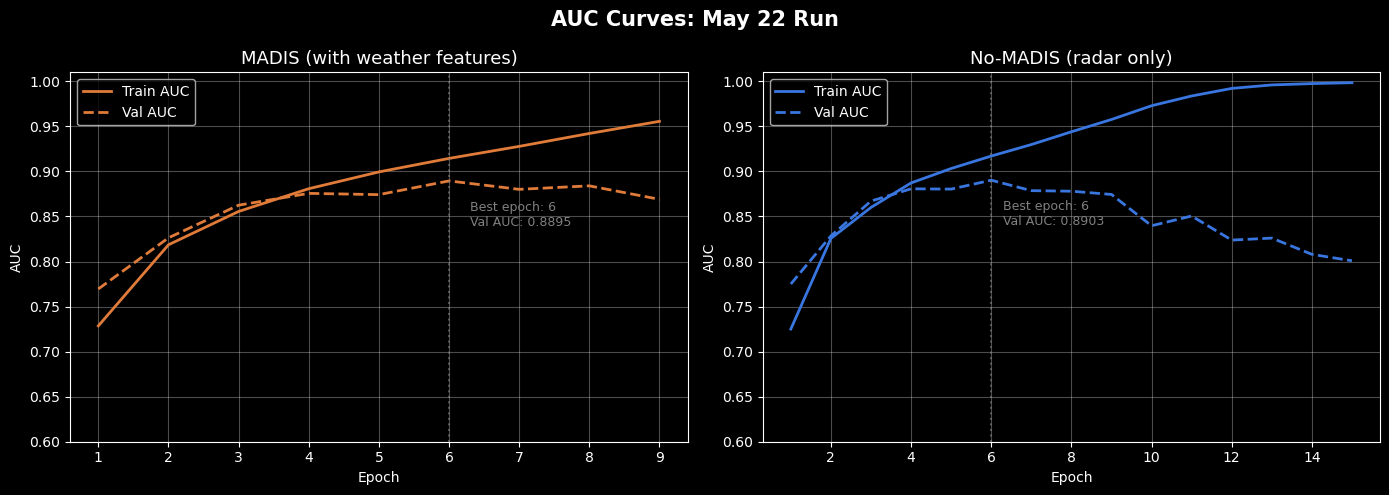

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS (with weather features)', 'No-MADIS (radar only)'],
    ['#e07b39', '#3976e0']
):
    ax.plot(df.index, df['AUC'],     color=color, linewidth=2, label='Train AUC')
    ax.plot(df.index, df['val_AUC'], color=color, linewidth=2, linestyle='--', label='Val AUC')
    best_epoch = df['val_AUC'].idxmax()
    ax.axvline(x=best_epoch, color='gray', linestyle=':', alpha=0.6)
    ax.annotate(f'Best epoch: {best_epoch}\nVal AUC: {df["val_AUC"].max():.4f}',
                xy=(best_epoch, df['val_AUC'].max()),
                xytext=(best_epoch + 0.3, df['val_AUC'].max() - 0.05),
                fontsize=9, color='gray')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('AUC')
    ax.set_ylim(0.6, 1.01)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('AUC Curves: May 22 Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/may22_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Loss Curves

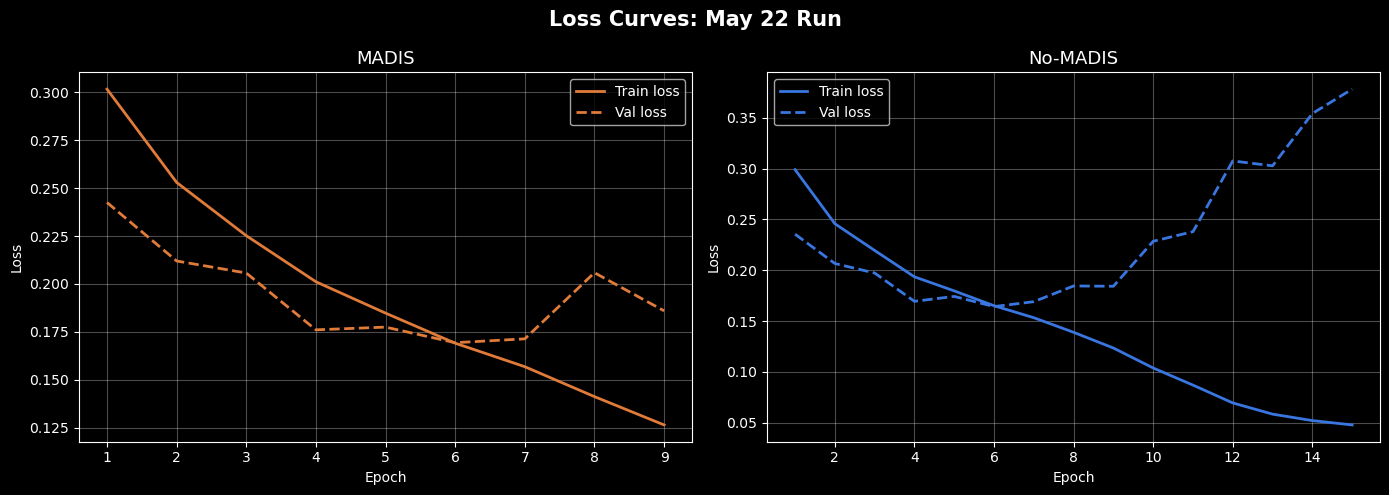

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS', 'No-MADIS'],
    ['#e07b39', '#3976e0']
):
    ax.plot(df.index, df['loss'],     color=color, linewidth=2, label='Train loss')
    ax.plot(df.index, df['val_loss'], color=color, linewidth=2, linestyle='--', label='Val loss')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Loss Curves: May 22 Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/may22_loss_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Head-to-Head Val Metrics at Best Epoch

In [5]:
best_cols = ['val_AUC', 'val_AUCPR', 'val_F1', 'val_Precision', 'val_Recall', 'val_loss']

best_madis    = madis.loc[madis['val_AUC'].idxmax()]
best_no_madis = no_madis.loc[no_madis['val_AUC'].idxmax()]

summary = pd.DataFrame({
    f'MADIS (epoch {madis["val_AUC"].idxmax()})':    best_madis[best_cols],
    f'No-MADIS (epoch {no_madis["val_AUC"].idxmax()})': best_no_madis[best_cols],
})
print(summary.round(4))

               MADIS (epoch 6)  No-MADIS (epoch 6)
val_AUC                 0.8895              0.8903
val_AUCPR               0.4710              0.4744
val_F1                  0.4740              0.4726
val_Precision           0.4625              0.4769
val_Recall              0.4861              0.4683
val_loss                0.1693              0.1642


## Val AUC Comparison Over Time

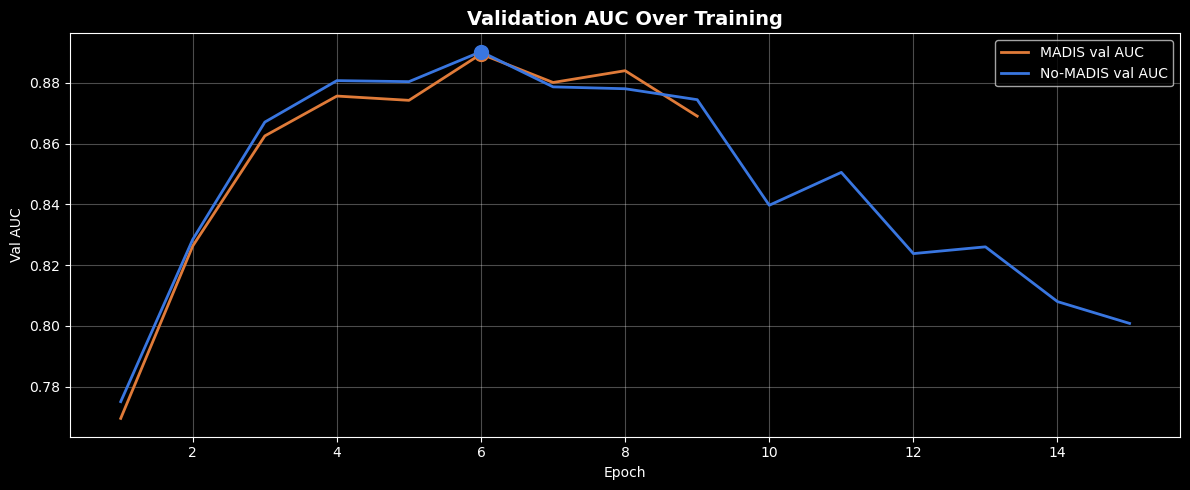

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(madis.index,    madis['val_AUC'],    color='#e07b39', linewidth=2, label='MADIS val AUC')
ax.plot(no_madis.index, no_madis['val_AUC'], color='#3976e0', linewidth=2, label='No-MADIS val AUC')

# Mark best epochs
ax.scatter([madis['val_AUC'].idxmax()],    [madis['val_AUC'].max()],    color='#e07b39', s=100, zorder=5)
ax.scatter([no_madis['val_AUC'].idxmax()], [no_madis['val_AUC'].max()], color='#3976e0', s=100, zorder=5)

ax.set_title('Validation AUC Over Training', fontsize=14, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Val AUC')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/may22_val_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Overfitting Gap

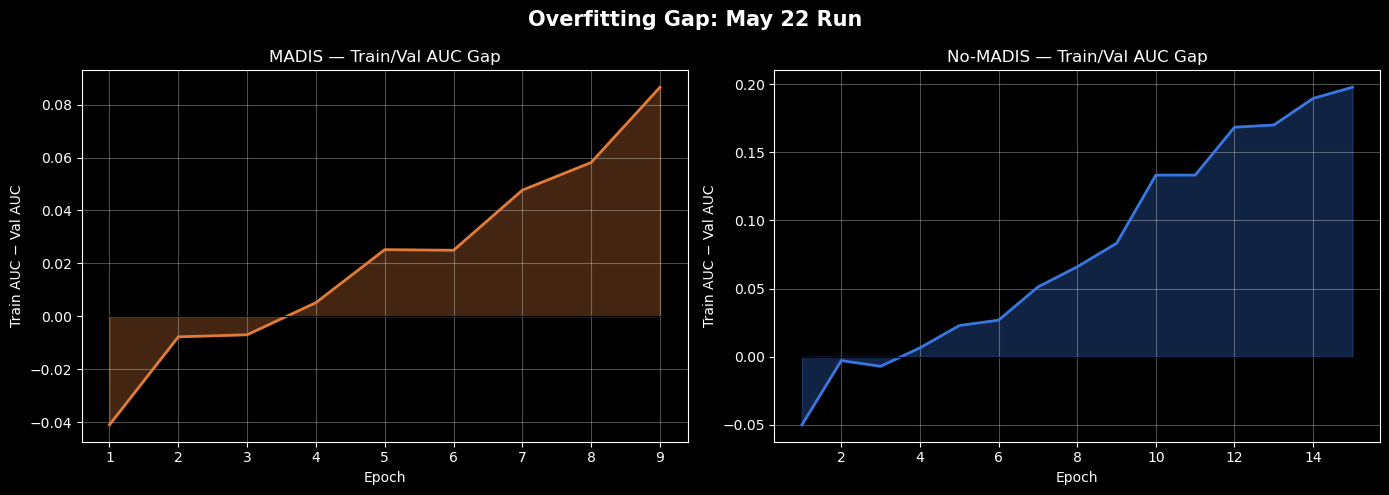

Final train/val AUC gap:
  MADIS (epoch 9):    0.0866
  No-MADIS (epoch 15): 0.1977


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, df, title, color in zip(
    axes,
    [madis, no_madis],
    ['MADIS', 'No-MADIS'],
    ['#e07b39', '#3976e0']
):
    gap = df['AUC'] - df['val_AUC']
    ax.fill_between(df.index, gap, alpha=0.3, color=color)
    ax.plot(df.index, gap, color=color, linewidth=2)
    ax.set_title(f'{title} — Train/Val AUC Gap', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train AUC − Val AUC')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Overfitting Gap: May 22 Run', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/may22_overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print('Final train/val AUC gap:')
print(f'  MADIS (epoch {len(madis)}):    {madis["AUC"].iloc[-1] - madis["val_AUC"].iloc[-1]:.4f}')
print(f'  No-MADIS (epoch {len(no_madis)}): {no_madis["AUC"].iloc[-1] - no_madis["val_AUC"].iloc[-1]:.4f}')

## Comparison with May 19 Run

In [8]:
may19_madis    = pd.read_csv('../results/run_may_19th/madis_history.csv')
may19_no_madis = pd.read_csv('../results/run_may_19th/no_madis_history.csv')
may19_madis.index    = range(1, len(may19_madis) + 1)
may19_no_madis.index = range(1, len(may19_no_madis) + 1)

print('Best val_AUC comparison across runs:')
print(f'  May 19 MADIS:    {may19_madis["val_AUC"].max():.4f} (epoch {may19_madis["val_AUC"].idxmax()})')
print(f'  May 19 No-MADIS: {may19_no_madis["val_AUC"].max():.4f} (epoch {may19_no_madis["val_AUC"].idxmax()})')
print(f'  May 22 MADIS:    {madis["val_AUC"].max():.4f} (epoch {madis["val_AUC"].idxmax()})')
print(f'  May 22 No-MADIS: {no_madis["val_AUC"].max():.4f} (epoch {no_madis["val_AUC"].idxmax()})')

Best val_AUC comparison across runs:
  May 19 MADIS:    0.8871 (epoch 4)
  May 19 No-MADIS: 0.9009 (epoch 13)
  May 22 MADIS:    0.8895 (epoch 6)
  May 22 No-MADIS: 0.8903 (epoch 6)


## Findings

### What happened

Both models peaked at **epoch 6** with nearly identical validation AUC:
- **MADIS best val_AUC**: ~0.889 — early stopping fired at epoch 9
- **No-MADIS best val_AUC**: ~0.890 — continued to epoch 15 and overfit significantly (val_AUC degraded to ~0.801)

### Key observations

1. **The models are essentially tied at their best epoch** — the MADIS features add no measurable benefit but also no longer hurt. This is an improvement over the May 19 run where MADIS actively hurt generalization.

2. **Early stopping worked correctly for MADIS** — it halted the run 6 epochs after peak, saving compute and preserving the best weights.

3. **No-MADIS also overfit** — val_AUC dropped from 0.890 to 0.801 over the final 9 epochs. The 1024/512 Dense head is still large enough to memorize training data given enough epochs. Early stopping should be applied to both runs.

4. **Both runs peaked at the same epoch** — this suggests the learning dynamics are nearly identical and the MADIS branch is contributing very little signal either way.

### Conclusion
The regularization improvements brought MADIS from actively harmful to neutral. The hypothesis that surface weather features add useful signal is not yet confirmed — but it is also not disproven. The MADIS branch may simply need more signal to learn from, or the current feature set may not be sufficiently discriminative.

## Next Steps

1. **Apply early stopping to both runs** — the no-MADIS model overfit just as badly after epoch 6. Add `"early_stopping_patience": 3` to `params_no_madis_comparison.json` for the next run.

2. **Evaluate on test set** — all analysis so far uses the validation set (2021–2022). Run `test_tornado_keras.py` on the best checkpoints to get final test metrics before drawing conclusions.

3. **Try a smaller head** — both models peaked at epoch 6 and then overfit. Consider reducing Dense layers further (512→256, 256→128) or switching back to maxpool head for the no-MADIS baseline.

4. **MADIS feature ablation** — the current MADIS branch uses all 7 features. Try using only the Tier-1 anomaly features (`pressure_anomaly_24h`, `wind_anomaly_24h`, `instability_proxy_T0/T2h`) which had the strongest Cohen's d signal in the data exploration notebook.

5. **More training data** — MADIS coverage improves in later years. If there are coverage gaps in 2013–2015 that cause many samples to be dropped, the MADIS model effectively trains on fewer samples than no-MADIS, putting it at a disadvantage.